# SBS Bank : analyse de l'activité clients et de la qualité de service

**Contexte.** SBS Bank est une néobanque fictive lancée en janvier 2025. Chaque client ouvre un compte associé à une carte de paiement et le gère depuis l'application (dépôts, virements, retraits). Après 18 mois, la direction veut savoir si la croissance est saine et où agir en priorité.

**Questions métier**

| # | Question | Requête SQL |
|---|---|---|
| Q1 | Quelle est la situation du portefeuille de comptes au 30 juin 2026 ? | `q01_global_kpis` |
| Q2 | La banque grandit-elle, et l'activité suit-elle l'acquisition ? | `q02_monthly_trend` |
| Q3 | Quel canal d'acquisition amène des clients qui utilisent réellement leur compte ? | `q03_activation_by_channel` |
| Q4 | L'engagement varie-t-il selon l'âge ? | `q04_lifecycle_by_age_band` |
| Q5 | Les clients restent-ils actifs dans les mois qui suivent l'ouverture ? | `q05_cohort_retention` |
| Q6 | Les encours sont-ils concentrés sur quelques clients ? | `q06_balance_concentration` |
| Q7 | Où les clients dépensent-ils avec leur carte ? | `q07_card_spend_by_category` |
| Q8 à Q10 | Où les clients rencontrent-ils des échecs, et pourquoi ? | `q08` à `q10` |
| Q11 et Q12 | Quels clients cibler pour prévenir la dormance ? | `q11`, `q12` |

**Méthode.** Les agrégations sont faites en SQL dans MySQL (fichier `sql/05_business_analysis.sql`, exécuté ici requête par requête). Python sert à ce que SQL fait mal : tests statistiques, segmentation, visualisation.

> Les données sont simulées (voir `docs/03_methodologie_et_choix.md`). Les chiffres commentés correspondent à la génération par défaut (`seed = 42`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency

from sbs_bank.analysis import (
    AQUA, BLUE, CHANNEL_COLORS, CHANNEL_LABELS, INK, INK_MUTED, INK_SECONDARY, ORANGE,
    REPORTS_DIR, SEQUENTIAL_BLUES, STATUS_LABELS, apply_style, euros, run_query, save_figure,
)

apply_style()
pd.set_option("display.max_columns", 30)

## 1. Contrôle qualité avant analyse

Aucune conclusion n'est fiable si les données ne le sont pas. On vérifie d'abord que les contrôles d'intégrité (`sql/03_data_quality_checks.sql`) renvoient tous 0 ligne en erreur, puis on consulte le bilan du nettoyage de l'export CRM.

In [2]:
checks = run_query("integrity_checks")
assert (checks["failing_rows"] == 0).all(), "Contrôle qualité en échec : analyse interrompue"
checks

,check_name,failing_rows
0,Solde différent de la somme des transactions,0
1,Numéro de carte invalide (algorithme de Luhn r...,0
2,Numéro de carte en double,0
3,Solde négatif,0
4,"Transaction liée à une opération échouée, d'un...",0
5,Opération monétaire réussie sans transaction,0
6,Opération antérieure à l'ouverture du compte,0
7,Opération réussie après la clôture du compte,0
8,Virement reçu par un compte clôturé,0
9,Compte clôturé avec un solde restant,0


In [3]:
run_query("crm_profiling")

,indicator,value
0,Lignes brutes dans l'export CRM,1884.0
1,Identifiants clients distincts,1800.0
2,Doublons écartés (anciennes versions ou copies),84.0
3,Orthographes différentes du canal d'inscription,13.0
4,Dates de naissance au format JJ/MM/AAAA,466.0
5,Prénoms ou noms avec espaces ou casse incohérente,380.0
6,Emails non normalisés (majuscules ou espaces),167.0
7,Villes non normalisées ou alias,263.0
8,Clients retenus dans la table customers,1800.0
9,Clients avec email invalide (valeur mise à NULL),18.0


**Lecture :** les données opérationnelles sont cohérentes (soldes égaux à la somme des transactions, numéros de carte valides, aucune opération hors période de vie du compte). L'export CRM contenait des doublons et des formats hétérogènes : ils ont été corrigés en SQL, et les valeurs inexploitables ont été mises à NULL avec un indicateur `dq_flags` plutôt que supprimées.

## 2. Vue d'ensemble du portefeuille (Q1)

In [4]:
kpis = run_query("q01_global_kpis").iloc[0]
pd.DataFrame({
    "Indicateur": [
        "Clients", "Comptes", "Comptes actifs", "Taux de comptes actifs", "Encours total",
        "Encours sur comptes dormants", "Dépôts cumulés", "Dépenses carte cumulées", "Solde moyen d'un compte actif",
    ],
    "Valeur": [
        f"{kpis.customers:.0f}", f"{kpis.accounts:.0f}", f"{kpis.active_accounts:.0f}", f"{kpis.active_rate_pct:.1f} %",
        euros(kpis.total_balances), euros(kpis.dormant_balances), euros(kpis.total_deposits),
        euros(kpis.total_card_spend), euros(kpis.avg_balance_active_account),
    ],
})

,Indicateur,Valeur
0,Clients,1800
1,Comptes,1881
2,Comptes actifs,1410
3,Taux de comptes actifs,75.0 %
4,Encours total,4 211 448 €
5,Encours sur comptes dormants,340 024 €
6,Dépôts cumulés,15 792 858 €
7,Dépenses carte cumulées,4 325 520 €
8,Solde moyen d'un compte actif,2 746 €


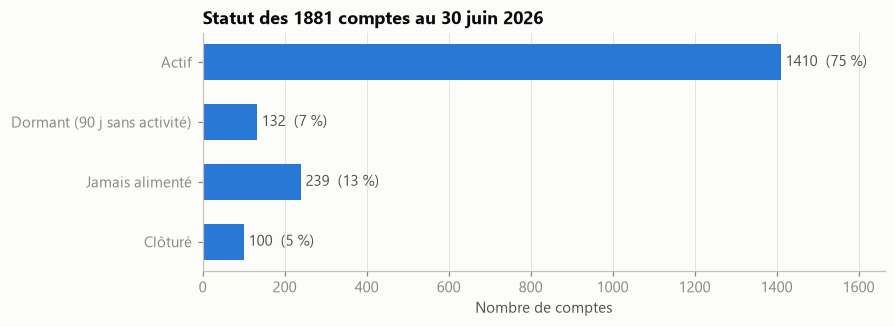

In [5]:
statuses = ["ACTIVE", "DORMANT", "NEVER_FUNDED", "CLOSED"]
counts = kpis[["active_accounts", "dormant_accounts", "never_funded_accounts", "closed_accounts"]].astype(int).to_numpy()

fig, ax = plt.subplots(figsize=(8, 2.8))
labels = [STATUS_LABELS[s] for s in statuses][::-1]
bars = ax.barh(labels, counts[::-1], color=BLUE, height=0.6)
for bar, value in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 12, bar.get_y() + bar.get_height() / 2,
            f"{value}  ({100 * value / counts.sum():.0f} %)", va="center", color=INK_SECONDARY)
ax.set_title(f"Statut des {counts.sum()} comptes au 30 juin 2026")
ax.set_xlabel("Nombre de comptes")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, counts.max() * 1.18)
save_figure(fig, "01_statut_des_comptes")
plt.show()

**Lecture :** 75 % des comptes sont actifs. Le principal gisement de progrès n'est pas la clôture (5 %) mais **les 239 comptes jamais alimentés (13 %)** : ces clients ont été acquis, donc payés, sans jamais utiliser le service. Les 132 comptes dormants immobilisent environ 340 000 €, soit 8 % des encours.

## 3. Croissance et activité mensuelle (Q2)

In [6]:
trend = run_query("q02_monthly_trend")
trend["month_start"] = pd.to_datetime(trend["month_start"])
trend[["month_start", "new_accounts", "cumulative_accounts", "active_accounts", "active_accounts_mom_pct",
       "card_spend_per_active_account", "app_failure_rate_pct", "card_decline_rate_pct"]]

,month_start,new_accounts,cumulative_accounts,active_accounts,active_accounts_mom_pct,card_spend_per_active_account,app_failure_rate_pct,card_decline_rate_pct
0,2025-01-01,69.0,69.0,59,NaN,74.14,8.03,22.16
1,2025-02-01,55.0,124.0,102,72.9,213.73,5.84,16.25
2,2025-03-01,67.0,191.0,161,57.8,265.38,6.59,13.90
3,2025-04-01,74.0,265.0,216,34.2,303.87,6.70,9.91
4,2025-05-01,88.0,353.0,293,35.6,280.80,5.41,9.03
5,2025-06-01,74.0,427.0,358,22.2,311.58,5.71,6.94
6,2025-07-01,92.0,519.0,431,20.4,406.23,6.36,10.34
7,2025-08-01,84.0,603.0,495,14.8,410.89,5.71,10.02
8,2025-09-01,183.0,786.0,630,27.3,311.55,6.01,8.67
9,2025-10-01,140.0,926.0,757,20.2,323.92,5.86,7.89


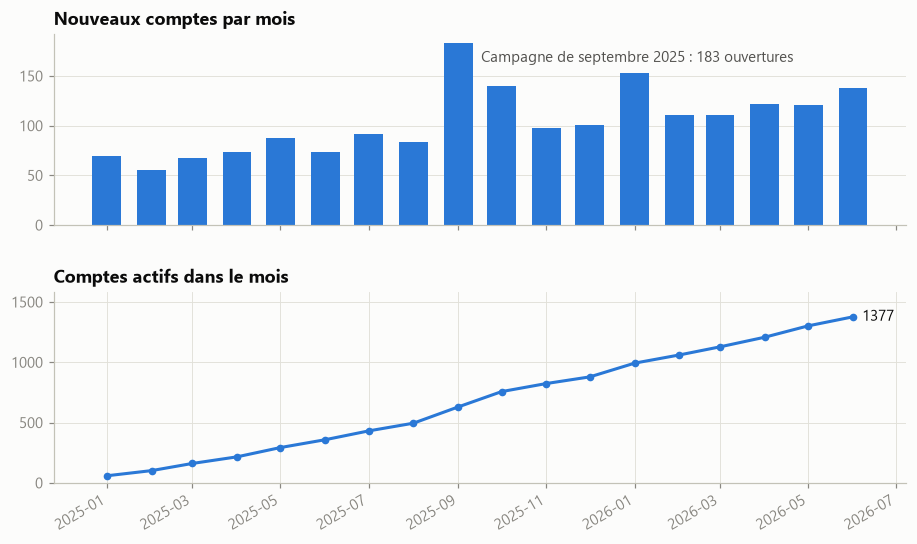

In [7]:
fig, (ax_new, ax_active) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"hspace": 0.35})
ax_new.bar(trend["month_start"], trend["new_accounts"], width=20, color=BLUE)
ax_new.set_title("Nouveaux comptes par mois")
ax_new.grid(axis="x", visible=False)
campaign = trend.loc[trend["new_accounts"].idxmax()]
ax_new.annotate(f"Campagne de septembre 2025 : {campaign.new_accounts:.0f} ouvertures",
                xy=(campaign.month_start, campaign.new_accounts), xytext=(15, -5), textcoords="offset points",
                color=INK_SECONDARY, va="top")

ax_active.plot(trend["month_start"], trend["active_accounts"], color=BLUE, marker="o", markersize=4)
ax_active.set_title("Comptes actifs dans le mois")
last = trend.iloc[-1]
ax_active.annotate(f"{last.active_accounts:.0f}", xy=(last.month_start, last.active_accounts),
                   xytext=(6, 0), textcoords="offset points", va="center", color=INK)
ax_active.set_ylim(0, trend["active_accounts"].max() * 1.15)
fig.autofmt_xdate()
save_figure(fig, "02_croissance_mensuelle")
plt.show()

**Lecture :**
- La base atteint **1 881 comptes** et **1 377 comptes actifs en juin 2026**. La campagne de septembre 2025 a doublé les ouvertures (183 contre 84 en août).
- La croissance du nombre de comptes actifs ralentit : de +20 % par mois à l'été 2025 à **+6 à +8 % par mois en 2026**. La banque entre dans une phase où la rétention compte autant que l'acquisition.
- La dépense carte par compte actif est saisonnière : pics en juillet et août (voyages) et en décembre (461 €, achats de fin d'année).
- Le taux de refus des paiements carte baisse de 22 % à 5,5 % : les premiers mois, la base est composée de comptes récents encore peu alimentés.

## 4. Activation selon le canal d'acquisition (Q3)

In [8]:
activation = run_query("q03_activation_by_channel").set_index("signup_channel")
activation

,accounts,funded_accounts,funded_within_7_days_pct,funded_within_30_days_pct,avg_days_to_first_deposit,active_rate_pct,never_funded_pct
signup_channel,,,,,,,
WEB,551,494.0,82.4,89.7,2.8,77.5,10.3
MOBILE,1007,911.0,83.5,90.4,2.7,76.6,9.5
PARTNER,185,135.0,35.1,68.6,11.1,59.5,27.0


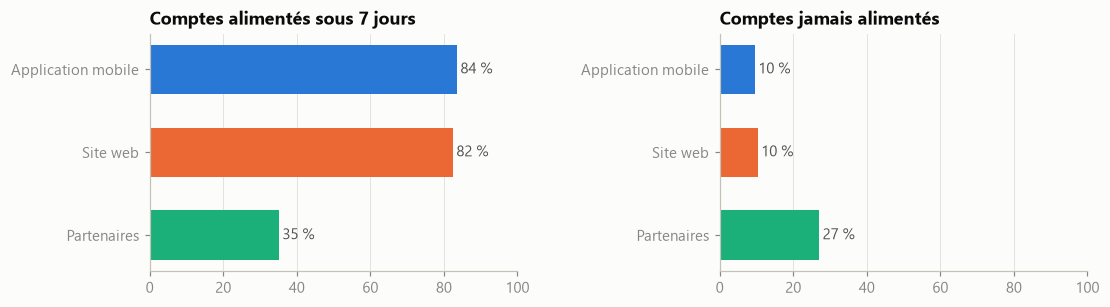

In [9]:
order = ["MOBILE", "WEB", "PARTNER"]
fig, axes = plt.subplots(1, 2, figsize=(11, 2.8), gridspec_kw={"wspace": 0.55})
panels = [("funded_within_7_days_pct", "Comptes alimentés sous 7 jours"), ("never_funded_pct", "Comptes jamais alimentés")]
for ax, (column, title) in zip(axes, panels):
    values = activation.loc[order[::-1], column]
    bars = ax.barh([CHANNEL_LABELS[c] for c in order[::-1]], values, color=[CHANNEL_COLORS[c] for c in order[::-1]], height=0.6)
    for bar, value in zip(bars, values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{value:.0f} %", va="center", color=INK_SECONDARY)
    ax.set_title(title)
    ax.set_xlim(0, 100)
    ax.grid(axis="y", visible=False)
save_figure(fig, "03_activation_par_canal")
plt.show()

**La différence est-elle significative ?** Un écart de pourcentages peut être dû au hasard sur de petits effectifs. Le test du khi-deux d'indépendance vérifie si l'alimentation du compte sous 30 jours dépend du canal. Le V de Cramér mesure la force de ce lien (0 = aucun lien, 1 = lien total).

In [10]:
detail = run_query("q03b_activation_detail")

def chi2_test(data):
    table = pd.crosstab(data["signup_channel"], data["funded_within_30_days"])
    chi2, p_value, dof, _ = chi2_contingency(table)
    cramers_v = np.sqrt(chi2 / (table.to_numpy().sum() * (min(table.shape) - 1)))
    return chi2, p_value, cramers_v

for label, subset in [("Trois canaux", detail), ("Mobile contre web", detail[detail["signup_channel"] != "PARTNER"])]:
    chi2, p_value, cramers_v = chi2_test(subset)
    print(f"{label:<18} khi2 = {chi2:6.1f}   p-value = {p_value:.2e}   V de Cramér = {cramers_v:.2f}")

Trois canaux       khi2 =   71.5   p-value = 2.98e-16   V de Cramér = 0.20
Mobile contre web  khi2 =    0.1   p-value = 7.18e-01   V de Cramér = 0.01


**Lecture :** les clients venus des **partenaires** activent beaucoup moins et beaucoup plus lentement : 35 % alimentent leur compte sous 7 jours contre 84 % via le mobile, et 27 % ne l'alimentent jamais contre 10 %. Le lien est statistiquement significatif (p-value très inférieure à 0,05). À l'inverse, **mobile et web ne diffèrent pas significativement** : le problème est propre au canal partenaire, pas au digital en général.

## 5. Rétention par cohorte d'ouverture (Q5)

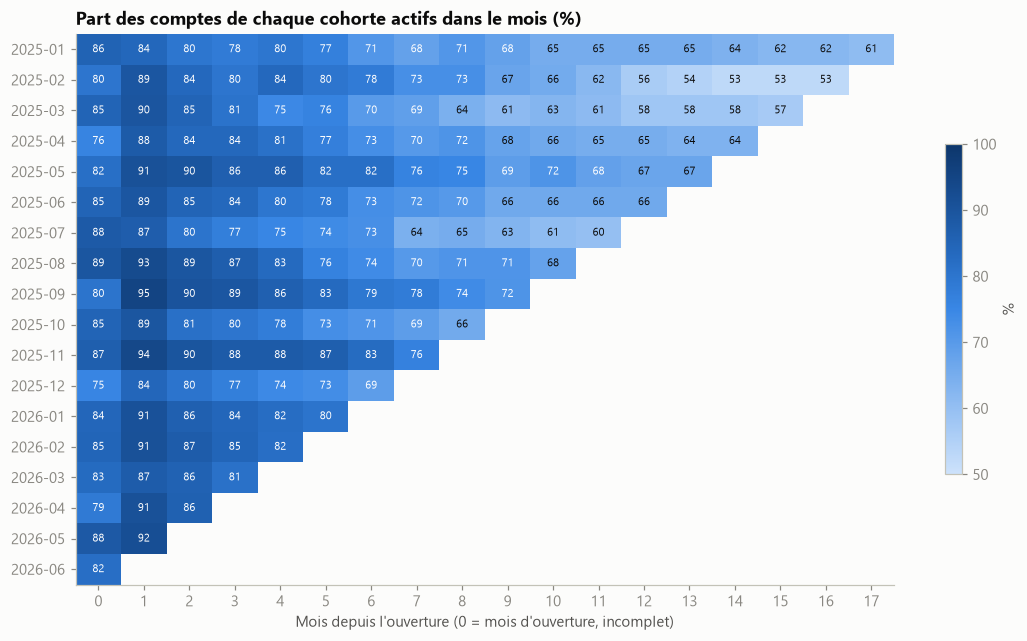

Rétention moyenne toutes cohortes : M1 = 90 %, M3 = 83 %, M6 = 75 %, M12 = 63 %


In [11]:
cohorts = run_query("q05_cohort_retention")
retention = cohorts.pivot(index="cohort_month", columns="months_since_opening", values="retention_pct")
retention.index = pd.to_datetime(retention.index).strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 6.5))
cmap = LinearSegmentedColormap.from_list("blues", SEQUENTIAL_BLUES)
image = ax.imshow(retention, cmap=cmap, vmin=50, vmax=100, aspect="auto")
for (row, col), value in np.ndenumerate(retention.to_numpy()):
    if not np.isnan(value):
        ax.text(col, row, f"{value:.0f}", ha="center", va="center", fontsize=7.5, color="white" if value >= 68 else INK)
ax.set_xticks(range(retention.shape[1]), retention.columns)
ax.set_yticks(range(retention.shape[0]), retention.index)
ax.set_xlabel("Mois depuis l'ouverture (0 = mois d'ouverture, incomplet)")
ax.set_title("Part des comptes de chaque cohorte actifs dans le mois (%)")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.6, label="%")
save_figure(fig, "04_retention_par_cohorte")
plt.show()

print("Rétention moyenne toutes cohortes :",
      ", ".join(f"M{m} = {retention[m].mean():.0f} %" for m in (1, 3, 6, 12) if m in retention))

**Lecture :** la rétention est élevée le premier mois puis s'érode régulièrement. Environ un compte sur quatre n'est plus actif au bout de 6 mois, et un sur trois au bout d'un an. La cohorte de la campagne de septembre 2025 retient au moins aussi bien que les autres : **la campagne a amené des clients de qualité**, ce qui plaide pour la reconduire.

## 6. Engagement selon l'âge (Q4)

In [12]:
run_query("q04_lifecycle_by_age_band")

,age_band,accounts,active_pct,dormant_pct,never_funded_pct,closed_pct,avg_balance_active,avg_card_spend_funded
0,18-24,356,76.7,6.2,12.1,5.1,2957.0,2286.0
1,25-34,614,74.3,8.3,12.1,5.4,2660.0,2911.0
2,35-44,401,75.3,6.0,13.5,5.2,2411.0,2538.0
3,45-54,228,73.7,7.5,13.2,5.7,2910.0,2542.0
4,55+,225,78.2,6.7,12.0,3.1,3146.0,2594.0
5,Inconnu,57,61.4,5.3,19.3,14.0,2303.0,3055.0


**Lecture :** l'âge discrimine peu l'engagement (74 à 78 % de comptes actifs selon la tranche). Il n'est donc pas un bon critère de ciblage, contrairement au canal d'acquisition. La ligne « Inconnu » (57 comptes sans date de naissance exploitable) montre l'effet de la qualité des données sur l'analyse ; l'effectif est trop faible pour conclure.

## 7. Valeur : concentration des encours et dépenses carte (Q6, Q7)

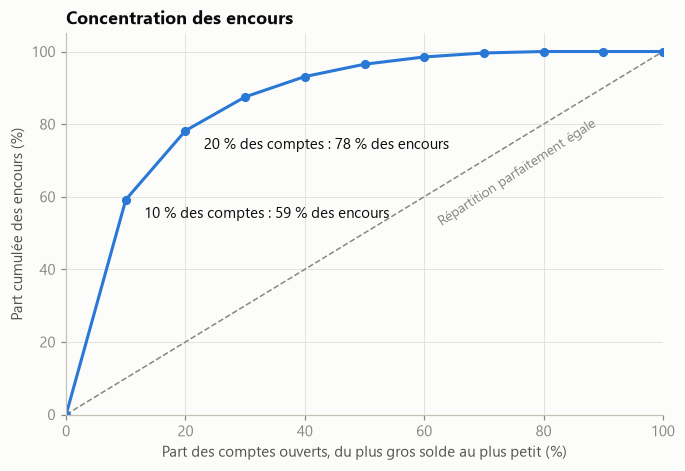

In [13]:
concentration = run_query("q06_balance_concentration")
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.concatenate([[0], concentration["balance_decile"] * 10])
y = np.concatenate([[0], concentration["cumulative_share_pct"]])
ax.plot([0, 100], [0, 100], color=INK_MUTED, linewidth=1, linestyle="--")
ax.text(62, 52, "Répartition parfaitement égale", color=INK_MUTED, rotation=33, fontsize=9)
ax.plot(x, y, color=BLUE, marker="o", markersize=5)
for decile in (1, 2):
    share = concentration.loc[decile - 1, "cumulative_share_pct"]
    ax.annotate(f"{decile * 10} % des comptes : {share:.0f} % des encours", xy=(decile * 10, share),
                xytext=(12, -12), textcoords="offset points", color=INK)
ax.set_xlabel("Part des comptes ouverts, du plus gros solde au plus petit (%)")
ax.set_ylabel("Part cumulée des encours (%)")
ax.set_title("Concentration des encours")
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
save_figure(fig, "05_concentration_des_encours")
plt.show()

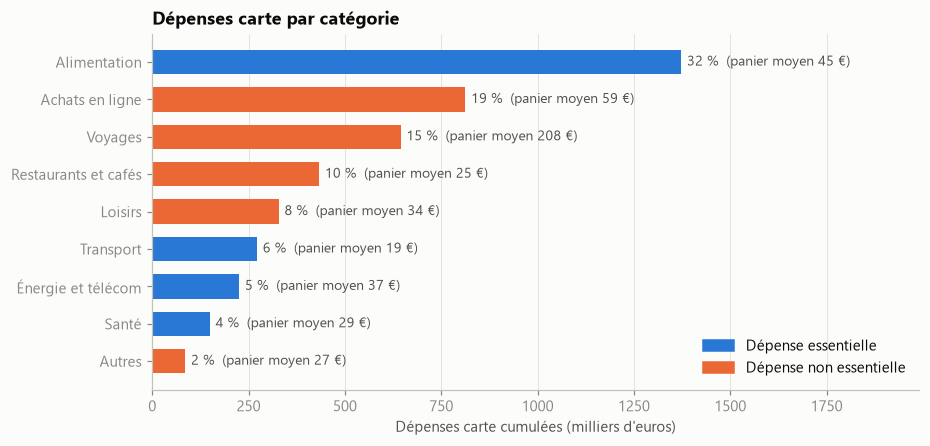

In [14]:
categories = run_query("q07_card_spend_by_category").sort_values("total_spend")
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [BLUE if essential else ORANGE for essential in categories["is_essential"]]
bars = ax.barh(categories["category"], categories["total_spend"] / 1000, color=colors, height=0.65)
for bar, share, ticket in zip(bars, categories["spend_share_pct"], categories["avg_ticket"]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f"{share:.0f} %  (panier moyen {ticket:.0f} €)", va="center", color=INK_SECONDARY, fontsize=9)
ax.set_xlabel("Dépenses carte cumulées (milliers d'euros)")
ax.set_title("Dépenses carte par catégorie")
ax.set_xlim(0, categories["total_spend"].max() / 1000 * 1.45)
ax.grid(axis="y", visible=False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)],
          labels=["Dépense essentielle", "Dépense non essentielle"], loc="lower right")
save_figure(fig, "06_depenses_par_categorie")
plt.show()

**Lecture :**
- **10 % des comptes détiennent 59 % des encours**, et 20 % en détiennent 78 %. Perdre quelques gros épargnants aurait un impact fort sur la collecte : ce segment justifie un suivi dédié.
- L'alimentation est le premier poste (32 % des dépenses), mais **plus de la moitié des dépenses sont non essentielles** (achats en ligne, voyages, restaurants, loisirs). Les voyages pèsent 15 % des montants avec un panier moyen d'environ 208 €, surtout en juillet et août : c'est un terrain naturel pour des offres partenaires (assurance voyage, cashback).

## 8. Qualité de service : échecs, erreurs de saisie et paiements refusés (Q8 à Q10)

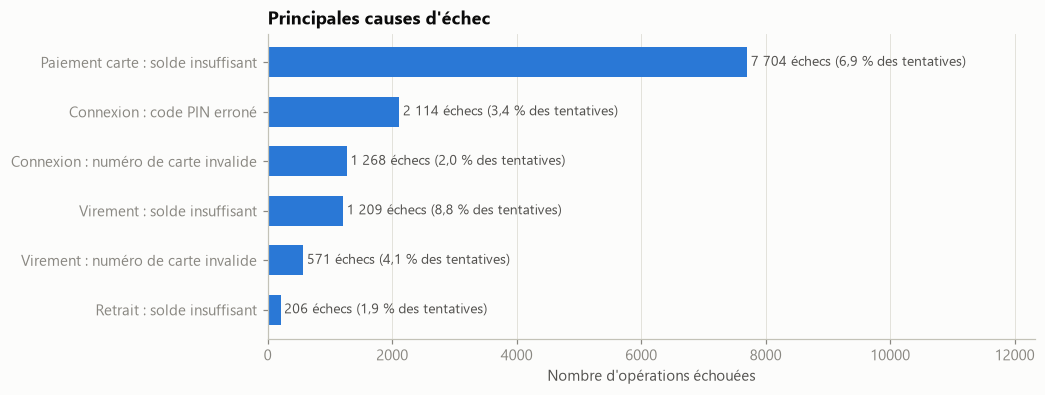

,event_type,failure_reason,failures,failure_rate_pct,share_of_all_failures_pct,amount_refused
0,CARD_PAYMENT,INSUFFICIENT_FUNDS,7704,6.92,57.8,521586.21
1,LOGIN,WRONG_PIN,2114,3.40,15.9,NaN
2,LOGIN,INVALID_CARD_NUMBER,1268,2.04,9.5,NaN
3,TRANSFER,INSUFFICIENT_FUNDS,1209,8.75,9.1,1830473.00
4,TRANSFER,INVALID_CARD_NUMBER,571,4.13,4.3,376398.00
5,WITHDRAWAL,INSUFFICIENT_FUNDS,206,1.95,1.5,2060.00
6,TRANSFER,ACCOUNT_CLOSED,86,0.62,0.6,62959.00
7,TRANSFER,SAME_ACCOUNT,56,0.41,0.4,30672.00
8,TRANSFER,UNKNOWN_CARD,43,0.31,0.3,28071.00
9,DEPOSIT,INVALID_AMOUNT,30,0.20,0.2,0.00


In [15]:
EVENT_LABELS = {"CARD_PAYMENT": "Paiement carte", "LOGIN": "Connexion", "TRANSFER": "Virement",
                "WITHDRAWAL": "Retrait", "DEPOSIT": "Dépôt"}
REASON_LABELS = {"INSUFFICIENT_FUNDS": "solde insuffisant", "WRONG_PIN": "code PIN erroné",
                 "INVALID_CARD_NUMBER": "numéro de carte invalide", "ACCOUNT_CLOSED": "bénéficiaire clôturé",
                 "SAME_ACCOUNT": "virement vers soi-même", "UNKNOWN_CARD": "carte inconnue",
                 "INVALID_AMOUNT": "montant invalide"}

failures = run_query("q08_failures_by_reason")
failures["label"] = failures["event_type"].map(EVENT_LABELS) + " : " + failures["failure_reason"].map(REASON_LABELS)
top = failures.head(6).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.barh(top["label"], top["failures"], color=BLUE, height=0.6)
for bar, rate in zip(bars, top["failure_rate_pct"]):
    ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():,.0f} échecs".replace(",", " ") + f" ({rate:.1f} % des tentatives)".replace(".", ","),
            va="center", color=INK_SECONDARY, fontsize=9)
ax.set_title("Principales causes d'échec")
ax.set_xlabel("Nombre d'opérations échouées")
ax.set_xlim(0, top["failures"].max() * 1.6)
ax.grid(axis="y", visible=False)
save_figure(fig, "07_causes_d_echec")
plt.show()
failures[["event_type", "failure_reason", "failures", "failure_rate_pct", "share_of_all_failures_pct", "amount_refused"]]

In [16]:
run_query("q09_card_number_errors")

,event_type,stopped_by_luhn_check,reached_database_lookup,card_number_errors,luhn_interception_pct
0,LOGIN,1268.0,11.0,1279,99.1
1,TRANSFER,571.0,43.0,614,93.0


In [17]:
run_query("q10_declined_payments_concentration")

,declines_band,accounts,accounts_pct,declined_payments,declines_pct
0,0 refus,605,37.3,0.0,0.0
1,1 à 2 refus,251,15.5,350.0,4.5
2,3 à 9 refus,476,29.3,2682.0,34.8
3,10 refus ou plus,290,17.9,4672.0,60.6


**Lecture :**
- **Les paiements carte refusés pour solde insuffisant représentent 58 % de tous les échecs** (6,9 % des tentatives, environ 520 000 € de paiements non réalisés). Pour le client, c'est une expérience frustrante ; pour la banque, un volume de paiements perdu.
- Ces refus sont concentrés : **18 % des porteurs de carte cumulent 61 % des refus**. Une action ciblée (alerte de solde bas, proposition d'un découvert encadré) peut traiter l'essentiel du problème.
- Le contrôle de Luhn intercepte **99 % des erreurs de numéro de carte à la connexion et 93 % sur les virements**, avant toute requête en base et avec un message immédiat pour le client. Les erreurs restantes sont des numéros formellement valides (erreur de copier-coller, inversion 0 et 9) que l'algorithme ne peut pas détecter par construction.
- 3,4 % des connexions échouent sur un code PIN erroné : un point d'attention pour le parcours de connexion (biométrie).

## 9. Segmentation des clients (Q12)

**Pourquoi segmenter ?** Traiter tous les clients de la même façon est coûteux et peu efficace. La méthode RFM est un standard du marketing client :

- **Récence** : nombre de jours depuis la dernière activité (seuils métier : 7, 30, 60 et 90 jours) ;
- **Fréquence** : nombre d'opérations sur les 180 derniers jours (quintiles) ;
- **Montant** : dépenses carte sur les 180 derniers jours (quintiles).

Le solde est ajouté pour repérer les épargnants, qui ont une forte valeur malgré une faible activité. Le calcul des indicateurs est fait en SQL ; le scoring et les règles de segmentation sont en Python, plus lisible et plus simple à faire évoluer.

In [18]:
rfm = run_query("q12_rfm_base")
rfm["R"] = pd.cut(rfm["recency_days"], bins=[-1, 7, 30, 60, 90, np.inf], labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency_180d"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["card_spend_180d"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
high_balance = rfm["balance_at_period_end"].quantile(0.75)

def segment(row):
    # Rules are evaluated in order: the first matching rule gives the segment
    if row.R >= 4 and row.F >= 4 and row.M >= 4:
        return "Champions"             # active this month, frequent, high card spend
    if row.F <= 2 and row.balance_at_period_end >= high_balance:
        return "Épargnants peu actifs"  # low activity but top 25 % balance
    if row.R == 1:
        return "Endormis"              # no activity for more than 90 days
    if row.R <= 3:
        return "À risque"              # no activity for 31 to 90 days
    if row.F >= 3:
        return "Clients réguliers"
    return "Occasionnels"              # recent but infrequent activity

rfm["segment"] = rfm.apply(segment, axis=1)
SEGMENT_ORDER = ["Champions", "Clients réguliers", "Épargnants peu actifs", "Occasionnels", "À risque", "Endormis"]

profile = (
    rfm.groupby("segment")
    .agg(comptes=("account_id", "count"), recence_moy_jours=("recency_days", "mean"),
         operations_180j=("frequency_180d", "mean"), depenses_carte_180j=("card_spend_180d", "mean"),
         solde_moyen=("balance_at_period_end", "mean"), encours=("balance_at_period_end", "sum"))
    .reindex(SEGMENT_ORDER)
)
profile["part_comptes_pct"] = 100 * profile["comptes"] / profile["comptes"].sum()
profile["part_encours_pct"] = 100 * profile["encours"] / profile["encours"].sum()
profile.round(1)

,comptes,recence_moy_jours,operations_180j,depenses_carte_180j,solde_moyen,encours,part_comptes_pct,part_encours_pct
segment,,,,,,,,
Champions,545,1.2,164.0,3403.0,1443.4,786643.1,35.3,18.7
Clients réguliers,363,3.1,74.1,937.0,4337.4,1574476.1,23.5,37.4
Épargnants peu actifs,166,52.8,35.5,451.1,9445.7,1567982.9,10.8,37.2
Occasionnels,326,3.7,28.1,371.3,482.2,157202.7,21.1,3.7
À risque,43,58.9,52.6,783.4,681.5,29305.1,2.8,0.7
Endormis,99,226.3,9.9,168.8,968.1,95838.6,6.4,2.3


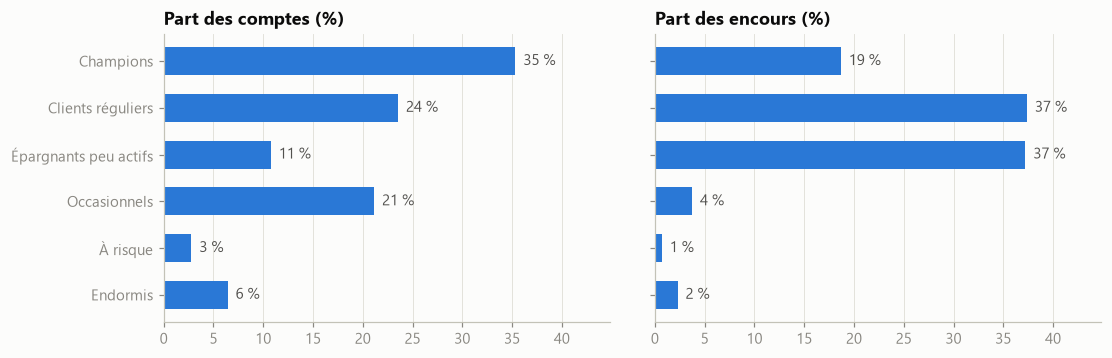

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True, gridspec_kw={"wspace": 0.1})
labels = SEGMENT_ORDER[::-1]
for ax, column, title in [(axes[0], "part_comptes_pct", "Part des comptes (%)"), (axes[1], "part_encours_pct", "Part des encours (%)")]:
    values = profile.loc[labels, column]
    bars = ax.barh(labels, values, color=BLUE, height=0.6)
    for bar, value in zip(bars, values):
        ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2, f"{value:.0f} %", va="center", color=INK_SECONDARY)
    ax.set_title(title)
    ax.set_xlim(0, max(profile["part_comptes_pct"].max(), profile["part_encours_pct"].max()) * 1.2)
    ax.grid(axis="y", visible=False)
save_figure(fig, "08_segments_rfm")
plt.show()

rfm[["account_id", "segment", "R", "F", "M", "recency_days", "frequency_180d", "card_spend_180d", "balance_at_period_end"]] \
    .to_csv(REPORTS_DIR / "segmentation_rfm.csv", index=False, encoding="utf-8-sig")

**Lecture :**

- **Champions (35 % des comptes)** : usage quotidien de la carte (164 opérations et environ 3 400 € de dépenses en 6 mois). Ils portent l'activité, mais seulement 19 % des encours. Action : cashback, parrainage.
- **Clients réguliers (24 % des comptes, 37 % des encours)** : base solide et bien dotée, à faire progresser vers un usage quotidien de la carte.
- **Épargnants peu actifs (11 % des comptes, 37 % des encours)** : solde moyen d'environ 9 400 €, faible usage, dernière activité il y a 53 jours en moyenne. C'est le segment le plus sensible : un départ silencieux ferait perdre une part importante de la collecte. Action : contact personnalisé, offre d'épargne rémunérée.
- **Occasionnels (21 %)** : actifs récemment mais peu fréquents, solde moyen faible (environ 480 €). Action : parcours d'accompagnement sur l'usage de la carte.
- **À risque (3 %)** et **Endormis (6 %)** : respectivement 31 à 90 jours et plus de 90 jours sans activité. Action : relance automatisée pour les premiers, campagne de réactivation pour les seconds, puis suivi réglementaire des comptes inactifs (loi Eckert au-delà de 12 mois).

## 10. Liste d'actions : clients actifs proches de la dormance (Q11)

In [20]:
watchlist = run_query("q11_dormancy_watchlist")
watchlist.to_csv(REPORTS_DIR / "liste_prevention_dormance.csv", index=False, encoding="utf-8-sig")
print(f"{len(watchlist)} comptes sans activité depuis 45 à 90 jours, "
      f"encours concerné : {euros(watchlist['balance_at_period_end'].sum())}")
watchlist.head(10)

38 comptes sans activité depuis 45 à 90 jours, encours concerné : 63 253 €


,account_id,customer_id,signup_channel,age_band,last_activity_at,days_since_last_activity,balance_at_period_end,card_payments
0,866,10808,MOBILE,35-44,2026-04-29 07:43:12,62,12577.99,21.0
1,859,10801,MOBILE,35-44,2026-04-26 19:30:53,65,6370.83,39.0
2,572,10539,WEB,55+,2026-04-28 13:12:20,63,4912.64,10.0
3,249,10236,WEB,45-54,2026-04-16 19:25:58,75,4759.20,77.0
4,1500,11421,MOBILE,25-34,2026-05-11 07:12:53,50,4661.10,10.0
5,691,10646,WEB,Inconnu,2026-04-28 15:33:53,63,3715.15,50.0
6,811,10753,WEB,55+,2026-05-01 19:18:36,60,3709.11,34.0
7,820,10762,WEB,35-44,2026-04-11 18:50:26,80,3545.77,41.0
8,807,10749,WEB,35-44,2026-05-02 20:34:07,59,2167.64,56.0
9,47,10044,PARTNER,55+,2026-05-15 18:15:35,46,2083.38,235.0


**Lecture :** cette liste est directement exploitable par l'équipe CRM (fichier `reports/liste_prevention_dormance.csv`). Les comptes sont triés par solde décroissant pour contacter en priorité ceux dont le départ coûterait le plus.

## 11. Synthèse et recommandations

### Réponses aux questions métier

| Question | Réponse |
|---|---|
| Q1. Situation du portefeuille | 1 881 comptes, **75 % actifs**, 13 % jamais alimentés, environ 340 000 € immobilisés sur des comptes dormants |
| Q2. Croissance | 1 377 comptes actifs en juin 2026 ; la croissance des actifs ralentit à **6 à 8 % par mois** en 2026 |
| Q3. Canal d'acquisition | Partenaires : **35 % de comptes alimentés sous 7 jours contre 84 %** en mobile ; écart significatif (p < 0,001) |
| Q4. Âge | Peu discriminant (74 à 78 % de comptes actifs selon la tranche) |
| Q5. Rétention | 90 % à 1 mois, **75 % à 6 mois**, 63 % à 12 mois ; la cohorte de la campagne de septembre 2025 retient bien |
| Q6 et Q7. Valeur | **10 % des comptes portent 59 % des encours** ; 53 % des dépenses carte sont non essentielles |
| Q8 à Q10. Qualité de service | Les paiements refusés représentent **58 % des échecs**, concentrés sur 18 % des porteurs ; le contrôle de Luhn bloque 93 à 99 % des erreurs de numéro de carte |
| Q11 et Q12. Ciblage | 6 segments ; les **épargnants peu actifs (11 % des comptes) portent 37 % des encours** ; 38 comptes à relancer avant dormance |

### Recommandations priorisées

1. **Revoir l'activation du canal partenaire** (impact le plus fort). Guider la première alimentation dès l'ouverture, relancer à J+3 et J+7, et conditionner la rémunération des partenaires à l'activation plutôt qu'à l'ouverture. Indicateur : part des comptes partenaires alimentés sous 7 jours (35 % aujourd'hui).
2. **Réduire les paiements refusés.** Alerte de solde bas et proposition d'un découvert encadré, ciblées sur les porteurs qui concentrent les refus. Indicateur : taux de refus carte (5,5 % en juin 2026).
3. **Sécuriser les encours des épargnants peu actifs.** Contact personnalisé et offre d'épargne pour les 166 comptes concernés.
4. **Industrialiser la prévention de la dormance.** Générer chaque mois la liste de la requête Q11 et déclencher une relance à 45 jours d'inactivité.
5. **Reconduire des campagnes d'acquisition du type septembre 2025**, dont les clients restent actifs au moins aussi longtemps que la moyenne.
6. **Fluidifier la connexion** (biométrie) pour réduire les 3,4 % d'échecs liés au code PIN, et conserver le contrôle de Luhn dans l'application.

### Limites

- Les données sont simulées : les tendances reflètent les hypothèses de la simulation. La démarche, les définitions et les requêtes sont en revanche directement transposables à des données réelles.
- Le coût d'acquisition et les revenus ne sont pas disponibles : la rentabilité par canal ne peut pas être calculée.
- Le seuil de dormance (90 jours) et les règles de segmentation sont des choix métier à valider avec les équipes concernées.